Dans ce script, nous allons tester différents modèles de type convolution Nelle pour examiner leur performance. Nous allons ensuite tester s'ils sont robustes lorsqu'on applique une rotation à l'image d'entrée.

# testing the FOVEA network for different rotations

In [1]:
import retinoto_py as fovea
args = fovea.Params(do_fovea=True, do_augment=False)
# args

In [2]:
all_angles = fovea.np.linspace(0, 180, 25)
all_angles

array([  0. ,   7.5,  15. ,  22.5,  30. ,  37.5,  45. ,  52.5,  60. ,
        67.5,  75. ,  82.5,  90. ,  97.5, 105. , 112.5, 120. , 127.5,
       135. , 142.5, 150. , 157.5, 165. , 172.5, 180. ])

In [3]:
all_model_names = fovea.params.all_model_names
all_model_names.append('convnext_base')
all_model_names = ['convnext_base']
all_model_names

['convnext_base']

In [4]:
all_datasets = ['bbox']
all_datasets

['bbox']

In [5]:
delta_angle = all_angles[1] - all_angles[0]
all_angles_min = all_angles - delta_angle / 2
# all_angles_min, all_angles_min + delta_angle, delta_angle

In [6]:
for dataset in all_datasets:
    for model_name in all_model_names:
        npz_filename = args.data_cache / f'37_rotation-attack_name={model_name}_dataset={dataset}.npz'
        print(f'Rotation attack for {model_name=} and {dataset=} \t {npz_filename=}')

        # %rm {npz_filename}  # FORCING RECOMPUTE

        if npz_filename.exists():
            with fovea.np.load(npz_filename) as data:
                attack_angle = data['attack_angle']
                attack_success = data['attack_success']
                all_results = data['results']
        else:
            args = fovea.Params(shuffle=False, do_fovea=True, do_augment=False, model_name=model_name, batch_size=500)
            VAL_DATA_DIR = args.DATAROOT / f'Imagenet_{dataset}' / 'val'
            model_filename = args.data_cache / f'32_fovea_model_name={args.model_name}_dataset={dataset}.pth'
            model = fovea.load_model(args, model_filename=model_filename)
            model.eval()

            val_dataset = fovea.get_dataset(args, VAL_DATA_DIR)
            val_loader = fovea.get_loader(args, val_dataset)

            # https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html 
            criterion = fovea.torch.nn.CrossEntropyLoss(reduction='none')
            # dataset_len = len(val_loader.dataset)
            num_classes = len(val_loader.dataset.classes)
            all_results = fovea.np.empty((len(all_angles), len(val_loader.dataset))) 
            all_logits = fovea.np.empty((len(all_angles), len(val_loader.dataset), num_classes))

            all_losses = fovea.np.empty((len(all_angles), len(val_loader.dataset))) 
            all_labels = []
            outer_progress = fovea.tqdm(
                                    enumerate(zip(all_angles_min, all_angles_min + delta_angle)),
                                    total=len(all_angles_min),
                                    desc="Validating Angles", 
                                    leave=False
                                )
            for i_angle, (angle_min, angle_max) in outer_progress:
                val_dataset = fovea.get_dataset(args, VAL_DATA_DIR, 
                                                angle_min=angle_min, angle_max=angle_max)
                val_loader = fovea.get_loader(args, val_dataset)

                # correct_predictions = 0
                # total_predictions = 0

                image_count = 0
                for images, true_idxs in fovea.tqdm(val_loader, desc=f"Angle [{.5*(angle_min+angle_max):.1f}°]", position=1, leave=False):
                    images = images.to(args.device)
                    true_idxs = true_idxs.to(args.device)

                    # Get predictions (no need for gradients)
                    with fovea.torch.no_grad():
                        if i_angle==0: all_labels.extend([l.item() for l in true_idxs])
                        outputs = model(images)
                        all_logits[i_angle, image_count:(image_count + images.size(0)), :] = outputs.cpu().numpy()
                        
                        _, predicted_labels = fovea.torch.max(outputs, dim=1)
                        correct_predictions_in_batch = (predicted_labels == true_idxs)

                        all_results[i_angle, image_count:image_count + images.size(0)] = correct_predictions_in_batch.cpu().numpy()
                        loss = criterion(outputs, true_idxs)
                        all_losses[i_angle, image_count:(image_count + images.size(0))] = loss.cpu().numpy()
                    image_count += images.size(0)
                outer_progress.set_postfix(last_acc=f"{all_results[i_angle, :].mean():.4f}")

            attack_angle = all_losses[:, :len(all_labels)].argmax(axis=0)
            attack_idx = all_logits[attack_angle[:len(all_labels)], fovea.np.arange(len(all_labels)), :].argmax(axis=1)
            attack_success = (attack_idx == all_labels)

            fovea.np.savez(npz_filename, 
                    attack_angle=attack_angle,
                    attack_success=attack_success,
                    results=all_results)



Rotation attack for model_name='convnext_base' and dataset='bbox' 	 npz_filename=PosixPath('cached_data/37_rotation-attack_name=convnext_base_dataset=bbox.npz')


Validating Angles:   0%|          | 0/25 [00:00<?, ?it/s]

Angle [0.0°]:   0%|          | 0/160 [00:00<?, ?it/s]

Angle [7.5°]:   0%|          | 0/160 [00:00<?, ?it/s]

Angle [15.0°]:   0%|          | 0/160 [00:00<?, ?it/s]

...

Angle [150.0°]:   0%|          | 0/160 [00:00<?, ?it/s]

Angle [157.5°]:   0%|          | 0/160 [00:00<?, ?it/s]

Angle [165.0°]:   0%|          | 0/160 [00:00<?, ?it/s]

Angle [172.5°]:   0%|          | 0/160 [00:00<?, ?it/s]

Angle [180.0°]:   0%|          | 0/160 [00:00<?, ?it/s]

# analysis: average accuracy for different rotations

In [7]:
all_results.shape

(25, 80475)

In [8]:
all_results.mean(axis=1)

array([0.79309102, 0.7908046 , 0.78951227, 0.78732526, 0.78522523,
       0.78267785, 0.77718546, 0.76951848, 0.76239826, 0.7558745 ,
       0.75068034, 0.74685306, 0.74500155, 0.74092575, 0.74133582,
       0.74287667, 0.74329916, 0.74532463, 0.74652998, 0.74594595,
       0.74808326, 0.74773532, 0.74884126, 0.74889096, 0.74904007])

FileNotFoundError: [Errno 2] No such file or directory: 'cached_data/37_rotation-attack_name=convnext_base_dataset=full.npz'

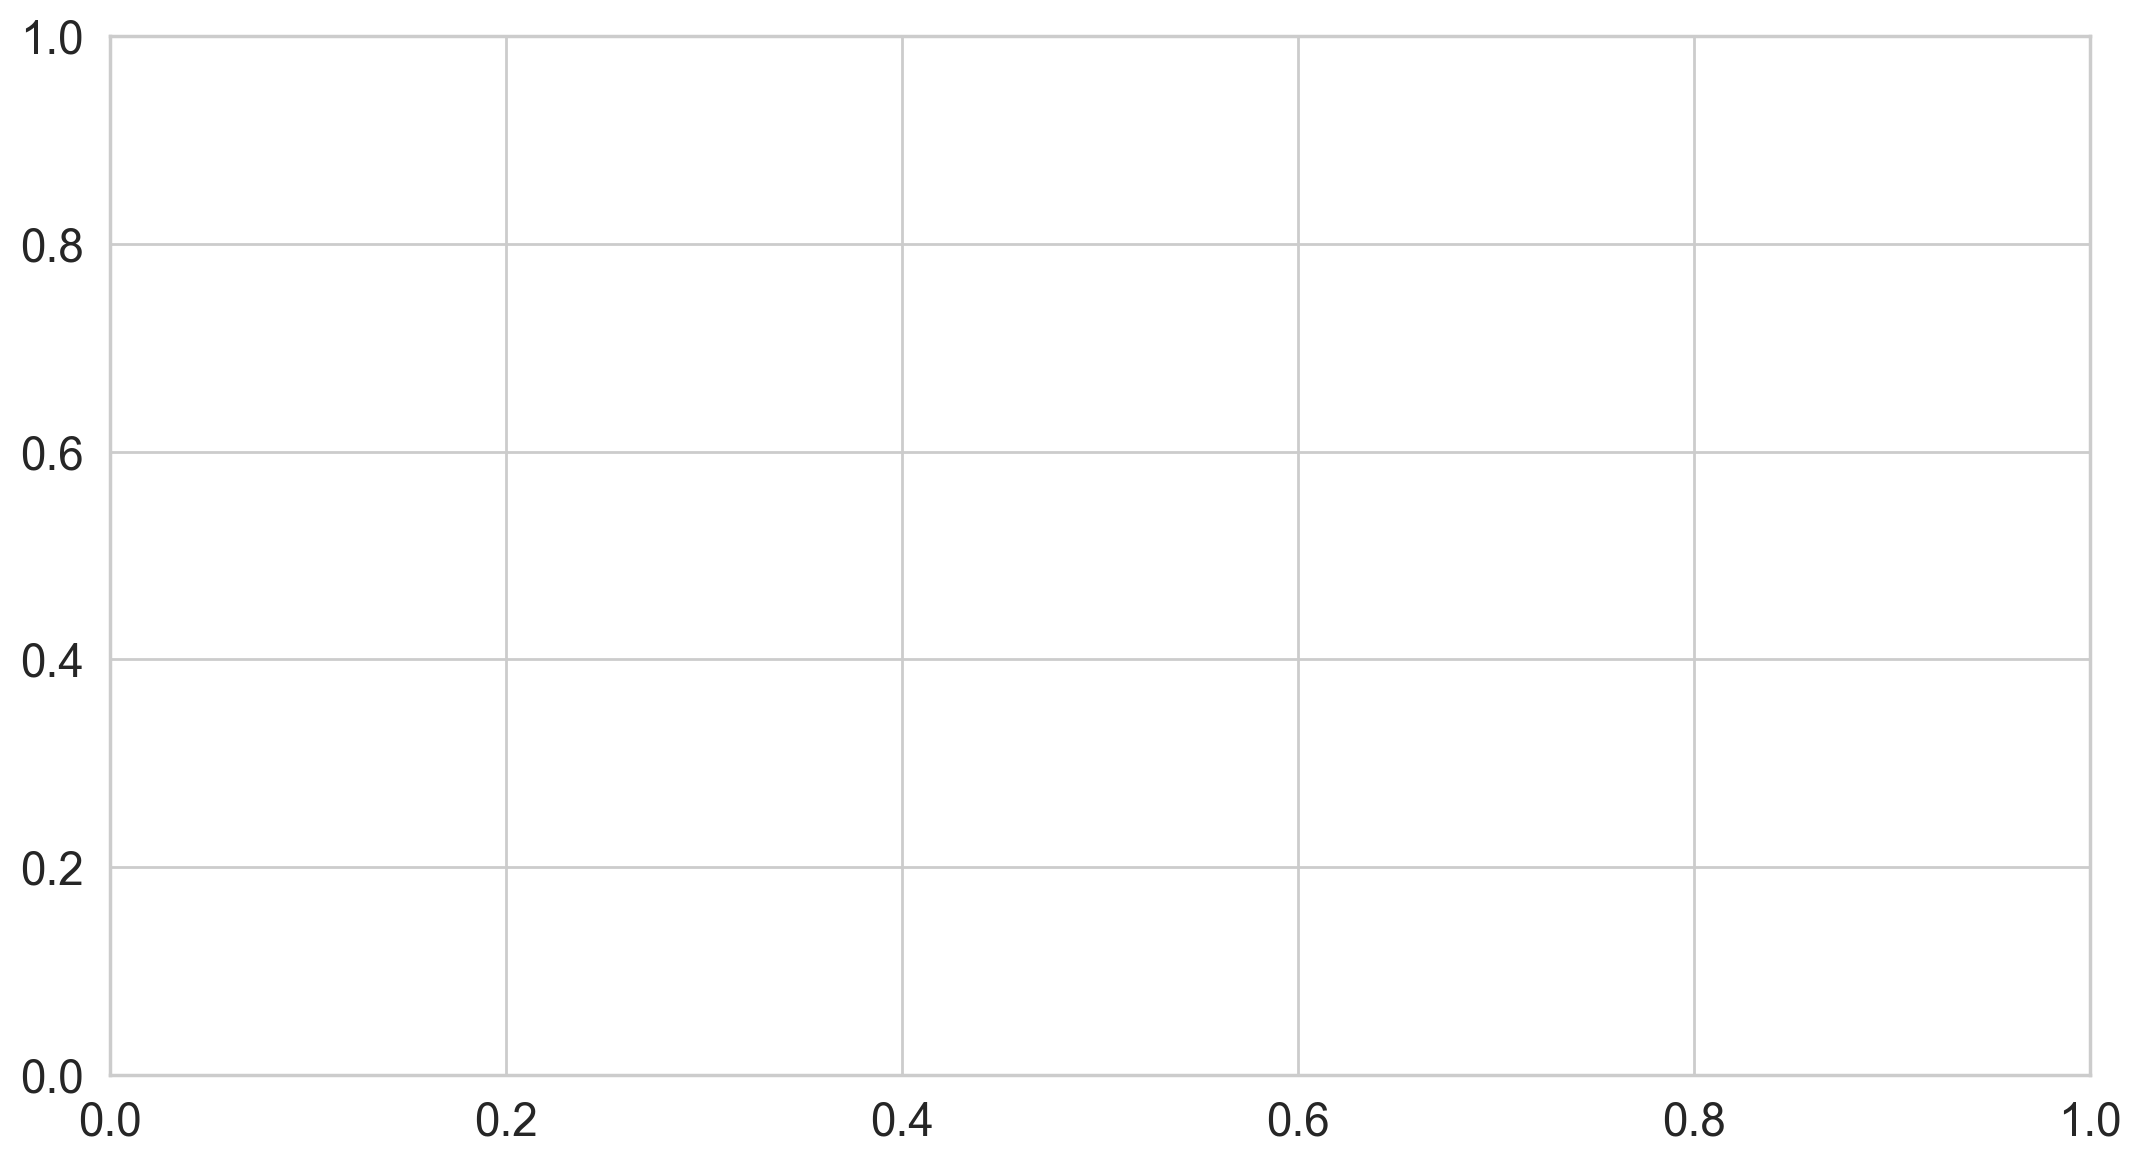

In [9]:
# --- Create the Plot ---
fig, ax = fovea.plt.subplots()

for dataset, color in zip(fovea.params.all_datasets, fovea.params.all_datasets_color):
    for model_name, ls in zip(all_model_names, fovea.params.all_model_names_ls):
        npz_filename = args.data_cache / f'37_rotation-attack_name={model_name}_dataset={dataset}.npz'
        with fovea.np.load(npz_filename) as data:
            all_results = data['results']
        # `all_results` is a boolean array (True/False for correct/incorrect)
        # To compute accuracy, average over the image axis (axis=1)
        mean_accuracy_per_angle = all_results.mean(axis=1)

        # Plot mean accuracy vs. reference angle
        ax.plot(all_angles, mean_accuracy_per_angle, marker='o', linestyle=ls, color=color, lw=2, markersize=8)

# --- Finalize the Plot ---
ax.set_xlabel("Image rotation angle (degrees)")
ax.set_ylabel("Mean accuracy")
ax.set_title("Model robustness to rotations")
# ax.set_ylim(0, 1.05)  # Ensure y axis spans 0 to 1
ax.set_yscale('logit')  # Ensure y axis spans 0 to 1

# Build legends
for dataset, color in zip(fovea.params.all_datasets, fovea.params.all_datasets_color):
    ax.plot([], [], linestyle='-', color=color, lw=2, label=dataset)
for model_name, ls in zip(all_model_names, fovea.params.all_model_names_ls):
    ax.plot([], [], linestyle=ls, color='k', lw=2, markersize=8, label=model_name)
ax.legend(frameon=False)


In [ ]:
all_model_names = fovea.params.all_model_names
all_model_names.append('convnext_base')
all_model_names = ['resnet18', 'resnet50', 'resnet101',  'convnext_base']
all_model_names_ls = [':', '-.', '--', '-'] 
all_model_names_c = ['magenta', 'blue', 'orange', 'green']

all_model_names 


In [ ]:
# --- Create the Plot ---
fig, ax = fovea.plt.subplots()
for model_name, c in zip(all_model_names, all_model_names_c):
    npz_filename = args.data_cache / f'17_rotation-attack_name={model_name}_dataset={dataset}.npz'
    with fovea.np.load(npz_filename) as data:
        all_results = data['results']
    # `all_results` is a boolean array (True/False for correct/incorrect)
    # To compute accuracy, average over the image axis (axis=1)
    mean_accuracy_per_angle = all_results.mean(axis=1)

    # Plot mean accuracy vs. reference angle
    ax.plot(all_angles[0], mean_accuracy_per_angle[0], marker='o', color=c, lw=2, markersize=8, label=model_name)

# model_name = 'convnext_base'
# npz_filename = args.data_cache / f'37_rotation-attack_name={model_name}_dataset={dataset}.npz'
# with fovea.np.load(npz_filename) as data:
#     all_results = data['results']
# mean_accuracy_per_angle = all_results.mean(axis=1)
# ax.plot(all_angles[0], mean_accuracy_per_angle[0], marker='D', linestyle=ls, color='r', lw=2, markersize=8, label='Foveated')

# --- Finalize the Plot ---
ax.set_xlabel(" ")
ax.set_ylabel("Mean accuracy")
ax.set_title("Model accuracy")
# ax.set_ylim(0, 1.05)  # Ensure y axis spans 0 to 1
ax.set_yscale('logit')  # Ensure y axis spans 0 to 1
ax.set_xticks(fovea.np.linspace(0, 180, 6))  # Ensure y axis spans 0 to 1
ax.set_xlim(-2, 182)  # Ensure y axis spans 0 to 1

# Build legends
# for dataset, color in zip(fovea.params.all_datasets, fovea.params.all_datasets_color):
#     ax.plot([], [], linestyle='-', color=color, lw=2, label=dataset)
# for model_name, ls in zip(all_model_names, fovea.params.all_model_names_ls):
#     ax.plot([], [], linestyle=ls, color='k', lw=2, markersize=8, label=model_name)
ax.legend(frameon=False)
for spine in ax.spines.values():
        spine.set_visible(False)
fovea.savefig(fig, name='37_attack_doublezero', figures_folder=args.figures_folder, exts=['pdf'])


In [ ]:
# --- Create the Plot ---
fig, ax = fovea.plt.subplots()
for model_name, c in zip(all_model_names, all_model_names_c):
    npz_filename = args.data_cache / f'17_rotation-attack_name={model_name}_dataset={dataset}.npz'
    with fovea.np.load(npz_filename) as data:
        all_results = data['results']
    # `all_results` is a boolean array (True/False for correct/incorrect)
    # To compute accuracy, average over the image axis (axis=1)
    mean_accuracy_per_angle = all_results.mean(axis=1)

    # Plot mean accuracy vs. reference angle
    ax.plot(all_angles[0], mean_accuracy_per_angle[0], marker='o', color=c, lw=2, markersize=8, label=model_name)

model_name = 'convnext_base'
npz_filename = args.data_cache / f'37_rotation-attack_name={model_name}_dataset={dataset}.npz'
with fovea.np.load(npz_filename) as data:
    all_results = data['results']
mean_accuracy_per_angle = all_results.mean(axis=1)
ax.plot(all_angles[0], mean_accuracy_per_angle[0], marker='D', linestyle=ls, color='r', lw=2, markersize=8, label='Foveated')

# --- Finalize the Plot ---
ax.set_xlabel(" ")
ax.set_ylabel("Mean accuracy")
ax.set_title("Model accuracy")
# ax.set_ylim(0, 1.05)  # Ensure y axis spans 0 to 1
ax.set_yscale('logit')  # Ensure y axis spans 0 to 1
ax.set_xticks(fovea.np.linspace(0, 180, 6))  # Ensure y axis spans 0 to 1
ax.set_xlim(-2, 182)  # Ensure y axis spans 0 to 1

# Build legends
# for dataset, color in zip(fovea.params.all_datasets, fovea.params.all_datasets_color):
#     ax.plot([], [], linestyle='-', color=color, lw=2, label=dataset)
# for model_name, ls in zip(all_model_names, fovea.params.all_model_names_ls):
#     ax.plot([], [], linestyle=ls, color='k', lw=2, markersize=8, label=model_name)
ax.legend(frameon=False)
for spine in ax.spines.values():
        spine.set_visible(False)
fovea.savefig(fig, name='37_attack_zero', figures_folder=args.figures_folder, exts=['pdf'])


In [ ]:
# --- Create the Plot ---
fig, ax = fovea.plt.subplots()
for model_name, c in zip(all_model_names, all_model_names_c):
    npz_filename = args.data_cache / f'17_rotation-attack_name={model_name}_dataset={dataset}.npz'
    with fovea.np.load(npz_filename) as data:
        all_results = data['results']
    # `all_results` is a boolean array (True/False for correct/incorrect)
    # To compute accuracy, average over the image axis (axis=1)
    mean_accuracy_per_angle = all_results.mean(axis=1)

    # Plot mean accuracy vs. reference angle
    ax.plot(all_angles, mean_accuracy_per_angle, marker='o', color=c, lw=2, markersize=8, label=model_name)

model_name = 'convnext_base'
npz_filename = args.data_cache / f'37_rotation-attack_name={model_name}_dataset={dataset}.npz'
with fovea.np.load(npz_filename) as data:
    all_results = data['results']
mean_accuracy_per_angle = all_results.mean(axis=1)
ax.plot(all_angles, mean_accuracy_per_angle, marker='D', linestyle=ls, color='r', lw=2, markersize=8, label='Foveated')

# --- Finalize the Plot ---
ax.set_xlabel("Image rotation angle (degrees)")
ax.set_ylabel("Mean accuracy")
ax.set_title("Model robustness to rotations")
# ax.set_ylim(0, 1.05)  # Ensure y axis spans 0 to 1
ax.set_yscale('logit')  # Ensure y axis spans 0 to 1
ax.set_xticks(fovea.np.linspace(0, 180, 6))  # Ensure y axis spans 0 to 1
ax.set_xlim(-2, 182)  # Ensure y axis spans 0 to 1

# Build legends
# for dataset, color in zip(fovea.params.all_datasets, fovea.params.all_datasets_color):
#     ax.plot([], [], linestyle='-', color=color, lw=2, label=dataset)
# for model_name, ls in zip(all_model_names, fovea.params.all_model_names_ls):
#     ax.plot([], [], linestyle=ls, color='k', lw=2, markersize=8, label=model_name)
ax.legend(frameon=False)
for spine in ax.spines.values():
        spine.set_visible(False)
fovea.savefig(fig, name='37_attack', figures_folder=args.figures_folder, exts=['pdf'])


In [ ]:
all_angles

In [ ]:
all_angles_wrap = fovea.np.hstack((all_angles, fovea.np.mod(all_angles[1:]+180, 360)))
all_angles_wrap

In [ ]:
all_angles_wrap_sub = fovea.np.hstack((all_angles[::4], fovea.np.mod(all_angles[::4][1:]+180, 360)))
all_angles_wrap_sub

In [ ]:
mean_accuracy_per_angle_wrap = fovea.np.hstack((mean_accuracy_per_angle, mean_accuracy_per_angle[:-1][::-1]))
mean_accuracy_per_angle_wrap

In [ ]:
# --- Création du Polar Plot ---

def figure_rotation_attack_polar(all_datasets, all_datasets_color, all_datasets_ls, 
                                 all_model_names, all_model_color, all_model_names_ls):
    # 1. Créer la figure et l'axe en projection polaire, all_model_names, all_model_names_ls
    fig = fovea.plt.figure()
    ax = fig.add_subplot(111, polar=True)

    # 2. Convertir les angles de degrés en radians (nécessaire pour Matplotlib)
    angles_rad = fovea.np.deg2rad(all_angles_wrap)

    for dataset, ls in zip(all_datasets, all_datasets_ls):
        for model_name, color in zip(all_model_names, all_model_color):
            npz_filename = args.data_cache / f'37_rotation-attack_name={model_name}_dataset={dataset}.npz'
            with fovea.np.load(npz_filename) as data:
                all_results = data['results']

            mean_accuracy_per_angle = all_results.mean(axis=1)
            mean_accuracy_per_angle_wrap = fovea.np.hstack((mean_accuracy_per_angle, mean_accuracy_per_angle[:-1][::-1]))
            ax.plot(angles_rad, fovea.np.sqrt(mean_accuracy_per_angle_wrap), marker='o', linestyle=ls, lw=2, markersize=8, color=color)
            ax.fill(angles_rad, fovea.np.sqrt(mean_accuracy_per_angle_wrap), alpha=0.05, color=color)
            # Ajouter la ligne de performance de base (angle=0)
            # Il faut trouver l'index de l'angle le plus proche de 0
            # zero_angle_idx = (fovea.np.abs(all_angles)).argmin()
            base_accuracy = mean_accuracy_per_angle_wrap[0] #zero_angle_idx]
            # ax.plot(angles_rad[zero_angle_idx], base_accuracy, 'rD', markersize=12, label=f'Performance de base: {base_accuracy:.2f}')
            ax.plot(angles_rad, fovea.np.sqrt(base_accuracy)*fovea.np.ones_like(mean_accuracy_per_angle_wrap), linestyle=ls, lw=1.5, alpha=.3, color=color)

    dataset_handles = []      # will store the handles for the dataset legend
    for dataset, ls in zip(all_datasets, all_datasets_ls):
        # Plot an *empty* line – it will never be shown on the figure,
        # but it gives us a handle with the right colour.
        h, = ax.plot([], [], linestyle=ls, color='k',
                    lw=2, label=dataset)
        dataset_handles.append(h)

    model_handles = []        # will store the handles for the model legend
    for model_name, color in zip(all_model_names, all_model_color):
        # Same idea, but now we vary the line style and keep the colour black.
        h, = ax.plot([], [], linestyle='-', color=color,
                    lw=2, markersize=8, label=model_name)
        model_handles.append(h)

    if len(all_datasets) > 1:
        # First legend – the *datasets* (coloured solid lines)
        leg_datasets = ax.legend(handles=dataset_handles,
                                labels=all_datasets,
                                title='Datasets',
                                loc='upper left',
                                bbox_to_anchor=(.85, 1.1),   # just outside the axes
                                frameon=False)

    if len(all_model_names) > 1:
        # Second legend – the *models* (different line‑styles)
        leg_models = ax.legend(handles=model_handles,
                            labels=all_model_names,
                            title='Models',
                            loc='upper left',
                            bbox_to_anchor=(.9, 0.25),  # lower than the first box
                            frameon=False)

    # IMPORTANT: add the first legend back to the Axes,
    # otherwise it would be overwritten by the second call.
    if len(all_datasets) > 1:
        ax.add_artist(leg_datasets)

    # ax.legend(loc='lower left', bbox_to_anchor=(1.05, 1.1))

    # --- Finalisation du Graphique Polaire ---
    # Définir la direction du zéro (haut) et le sens horaire/anti-horaire
    ax.set_theta_zero_location('N')
    ax.set_theta_direction(-1) # -1 pour horaire, 1 pour anti-horaire

    # Définir les étiquettes des angles sur le cercle
    # S'assurer que les étiquettes sont alignées
    ax.set_thetagrids(fovea.np.degrees(angles_rad), labels=[f'{a:.0f}°' for a in all_angles_wrap])

    # Définir les limites et les étiquettes de l'axe radial (l'accuracy)
    # ax.set_xlim(0)
    # ax.set_yscale('logit')
    ax.set_ylim(0, 1.05)
    # ax.set_ylim(0)
    # ax.set_ylabel("Accuracy moyenne", labelpad=30) # labelpad pour éloigner l'étiquette du graphique
    ax.set_rlabel_position(45) # Positionner l'étiquette de l'axe radial

    ax.set_xticks(fovea.np.deg2rad(all_angles_wrap_sub))
    # ax.set_yticks([])

    # Ajouter un titre
    # ax.set_title(f"Robustesse du modèle ({args.model_name}) aux rotations\n(Accuracy vs. Angle)", pad=20)
    return fig, ax

fig, ax = figure_rotation_attack_polar(fovea.params.all_datasets, fovea.params.all_datasets_color, fovea.params.all_datasets_ls, all_model_names, all_model_names_color, all_model_names_ls)

In [ ]:
fig, ax = figure_rotation_attack_polar(fovea.params.all_datasets[:1], fovea.params.all_datasets_color[:1], fovea.params.all_datasets_ls, all_model_names, all_model_names_color, all_model_names_ls)

In [ ]:
fig, ax = figure_rotation_attack_polar(fovea.params.all_datasets[:1], fovea.params.all_datasets_color[:1], fovea.params.all_datasets_ls, all_model_names, ['green', 'blue', 'orange'], ['-', '-', '-'])
fovea.savefig(fig, name='17_attack', figures_folder=args.figures_folder, exts=['svg'])

# analysis: per image rotation attack

In [ ]:
attack_angle.shape, attack_success.shape

In [ ]:
fovea.np.unique(attack_angle)

In [ ]:
all_angles

In [ ]:
attack_success

In [ ]:
attack_success.mean()

In [ ]:
all_model_names

In [ ]:
fovea.params.all_datasets

In [ ]:
for dataset in fovea.params.all_datasets:
    for model_name in all_model_names:
        npz_filename = args.data_cache / f'17_rotation-attack_name={model_name}_dataset={dataset}.npz'
        with fovea.np.load(npz_filename) as data:
            attack_success = data['attack_success']
            print(npz_filename, attack_success.mean())

In [ ]:
for dataset in fovea.params.all_datasets:
    for model_name in all_model_names:
        npz_filename = args.data_cache / f'37_rotation-attack_name={model_name}_dataset={dataset}.npz'
        with fovea.np.load(npz_filename) as data:
            attack_success = data['attack_success']
            print(npz_filename, attack_success.mean())

In [ ]:
attack_angle
